In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab
from matplotlib import legend_handler

# Fijamos el estilo de la gráfica
sns.set_theme()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [3]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [4]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Comparación bootstraps sin estratificar

In [132]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_s_e=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_sin_est_f_1.csv", index_col=0)
# Base de bootstrap por votos (directo)
df_boostraps_votos_se=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Directo/Distintas_muestras_bootstrap_votos_dir_sin_est_f_1.csv", index_col=0)

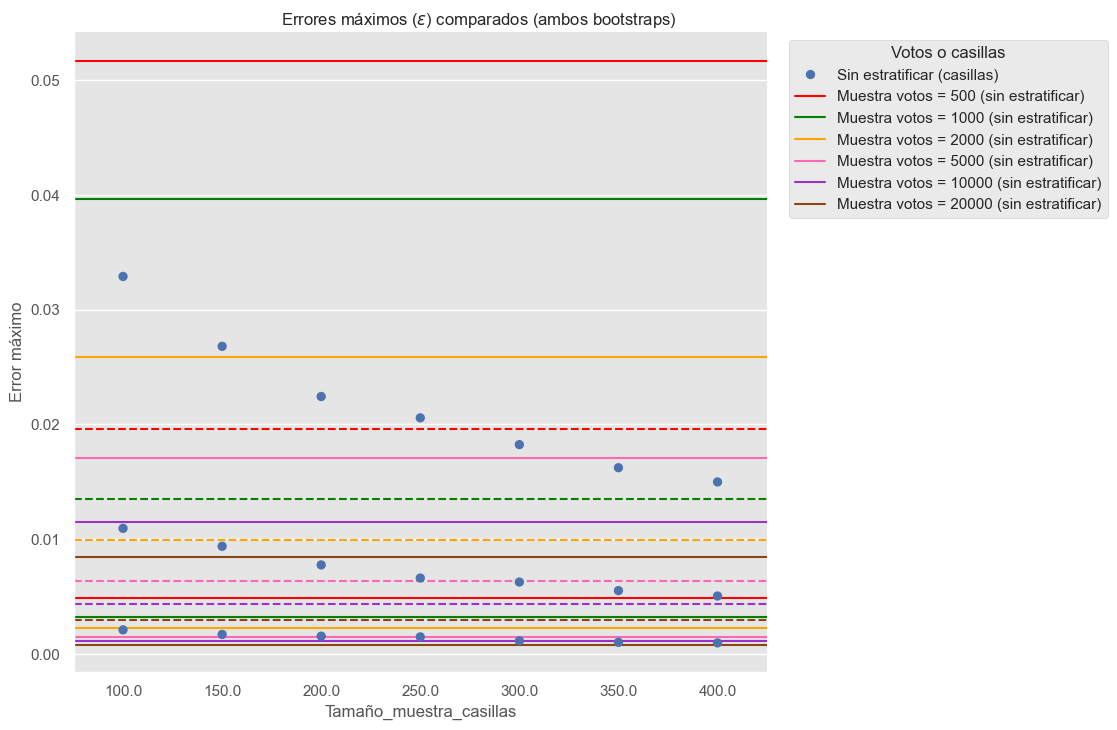

In [137]:
plt.style.use('ggplot')
# Para hacer la gráfica del error con los distintos tamaños de la submuestra de votos
df_grafica_error_aux_comb_1=pd.melt(df_boostraps_c_s_e[["Tamaño_muestra_casillas", "Estratificación", "Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)
per_e=sns.catplot(data=df_grafica_error_aux_comb_1, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', palette="deep", jitter=False, dodge=True, s = 45, height=7.4, aspect=1.1);
per_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Error máximo')
per_e.figure.subplots_adjust(top=0.95)
per_e.figure.suptitle('Errores máximos ($\\epsilon$) comparados (ambos bootstraps)');

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Error_maximo_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');
#per_e.refline(y=0.015, linewidth=1, color='black', ls='--');


# extract the catplot artist legend handles
catplot_handles = per_e._legend.legend_handles

# make the in built catplot legend invisible
per_e._legend.set(visible=False)

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

In [134]:
df_boostraps_votos_se

,Tamaño_muestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,500.0,0.004824,0.019602,0.051655,JOAQUIN_DIAZ_MENA,0.952,0.082131,0.087116,0.092539,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.910,0.000000,0.011112,0.019078,0.952,0.947,0.937,0.946,0.910
1,1000.0,0.003232,0.013484,0.039606,JOAQUIN_DIAZ_MENA,0.944,0.058242,0.061574,0.065029,VIDA_ARAVARI_GOMEZ_HERRERA,0.940,0.019216,0.023106,0.026770,0.944,0.956,0.940,0.955,0.951
2,2000.0,0.002248,0.009932,0.025851,JOAQUIN_DIAZ_MENA,0.950,0.041188,0.043621,0.046381,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.935,0.004111,0.006175,0.008155,0.950,0.944,0.948,0.950,0.935
3,5000.0,0.001491,0.006316,0.017107,JOAQUIN_DIAZ_MENA,0.940,0.025989,0.027615,0.029219,RENAN_BARRERA_CONCHA,0.935,0.025735,0.027276,0.028833,0.940,0.935,0.949,0.940,0.957
4,10000.0,0.001141,0.004368,0.011455,JOAQUIN_DIAZ_MENA,0.954,0.018488,0.019588,0.020744,VOTOS_NULOS_CAND_NO_REGIS,0.941,0.005159,0.005662,0.006162,0.954,0.953,0.955,0.941,0.961
5,20000.0,0.000794,0.002980,0.008404,JOAQUIN_DIAZ_MENA,0.943,0.013120,0.013913,0.014658,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.938,0.001779,0.002004,0.002236,0.943,0.950,0.943,0.958,0.938


In [135]:
df_boostraps_c_s_e

,Tamaño_muestra_casillas,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE,Estratificación
0,100.0,0.002091,0.010938,0.032888,JOAQUIN_DIAZ_MENA,0.953,0.043243,0.054123,0.064861,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.767,0.001334,0.003784,0.011767,0.953,0.949,0.910,0.935,0.767,Sin estratificar (casillas)
1,150.0,0.001695,0.009373,0.026799,JOAQUIN_DIAZ_MENA,0.947,0.037632,0.044825,0.052716,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.765,0.001162,0.003264,0.008237,0.947,0.944,0.921,0.929,0.765,Sin estratificar (casillas)
2,200.0,0.001543,0.007747,0.022424,JOAQUIN_DIAZ_MENA,0.963,0.034233,0.039154,0.045507,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.841,0.001110,0.003103,0.006707,0.963,0.962,0.947,0.935,0.841,Sin estratificar (casillas)
3,250.0,0.001480,0.006607,0.020565,JOAQUIN_DIAZ_MENA,0.963,0.031191,0.035606,0.040110,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.880,0.001068,0.002899,0.006002,0.963,0.959,0.944,0.938,0.880,Sin estratificar (casillas)
4,300.0,0.001133,0.006256,0.018233,JOAQUIN_DIAZ_MENA,0.966,0.029029,0.032729,0.036931,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.885,0.000992,0.002691,0.005223,0.966,0.968,0.956,0.942,0.885,Sin estratificar (casillas)
5,350.0,0.001005,0.005511,0.016222,JOAQUIN_DIAZ_MENA,0.969,0.027294,0.030655,0.034343,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.902,0.001055,0.002519,0.004701,0.969,0.975,0.958,0.947,0.902,Sin estratificar (casillas)
6,400.0,0.000956,0.005041,0.014980,JOAQUIN_DIAZ_MENA,0.975,0.025912,0.028907,0.032051,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.929,0.001027,0.002452,0.004369,0.975,0.974,0.960,0.957,0.929,Sin estratificar (casillas)


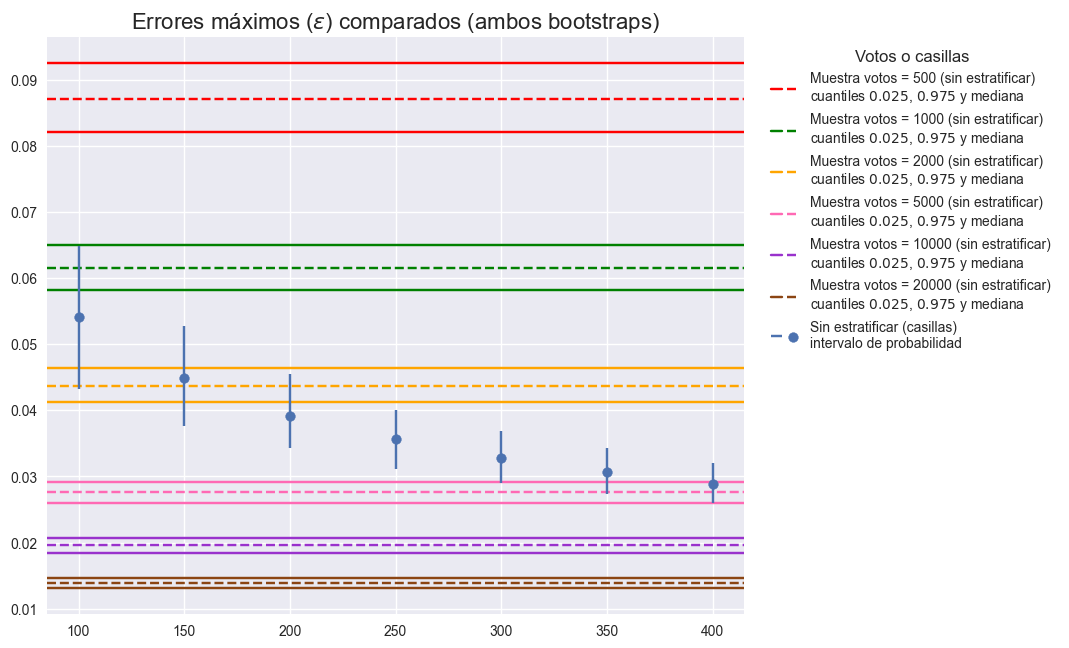

In [145]:

plt.style.use('seaborn-v0_8')
# Tamaño de la gráfica
fig = plt.figure(figsize=(9, 7.5))
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas=[]

# Para graficar todos las rectas de los votos

for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    # Guardamos en lista los labels
    labels_votos.append(f"Muestra votos = {i[1]} (sin estratificar) \ncuantiles $0.025$, $0.975$ y mediana");
    line_1=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    
    line_3=ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    lista_graficas.append((line_1,line_3));
    ax.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# Gráficas de los intervalos de confianza del bootstrap de casillas

# Cuantiles 0.025 y 0.975
i=0
for val in df_boostraps_c_s_e["Tamaño_muestra_casillas"].values:
    if i == 0:
        line_2=ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_975"].values, color='C0', zorder = 5, label='Sin estratificar (casillas)');
    else:
        ax.vlines(val, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_025"].values, df_boostraps_c_s_e[df_boostraps_c_s_e["Tamaño_muestra_casillas"]==val]["Intervalo_M_grande_inter_q_975"].values, color='C0', zorder = 5)
    i+=1
# Mediana
punto_1=ax.scatter(df_boostraps_c_s_e["Tamaño_muestra_casillas"],df_boostraps_c_s_e["Intervalo_M_grande_inter_mediana"], color='C0', zorder = 5, label='Sin estratificar (casillas) \npru');

# Agregamos el label para las casillas
labels_votos.append("Sin estratificar (casillas) \nintervalo de probabilidad")

# Agregamos la tupla de las gráficas de casillas
lista_graficas.append((line_2,punto_1))

# Juntamos los títulos y las leyendas con un nombre
#legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))

lgnd = ax.legend(lista_graficas, labels_votos, title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.title('Errores máximos ($\\epsilon$) comparados (ambos bootstraps)', fontsize=16);
#plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");


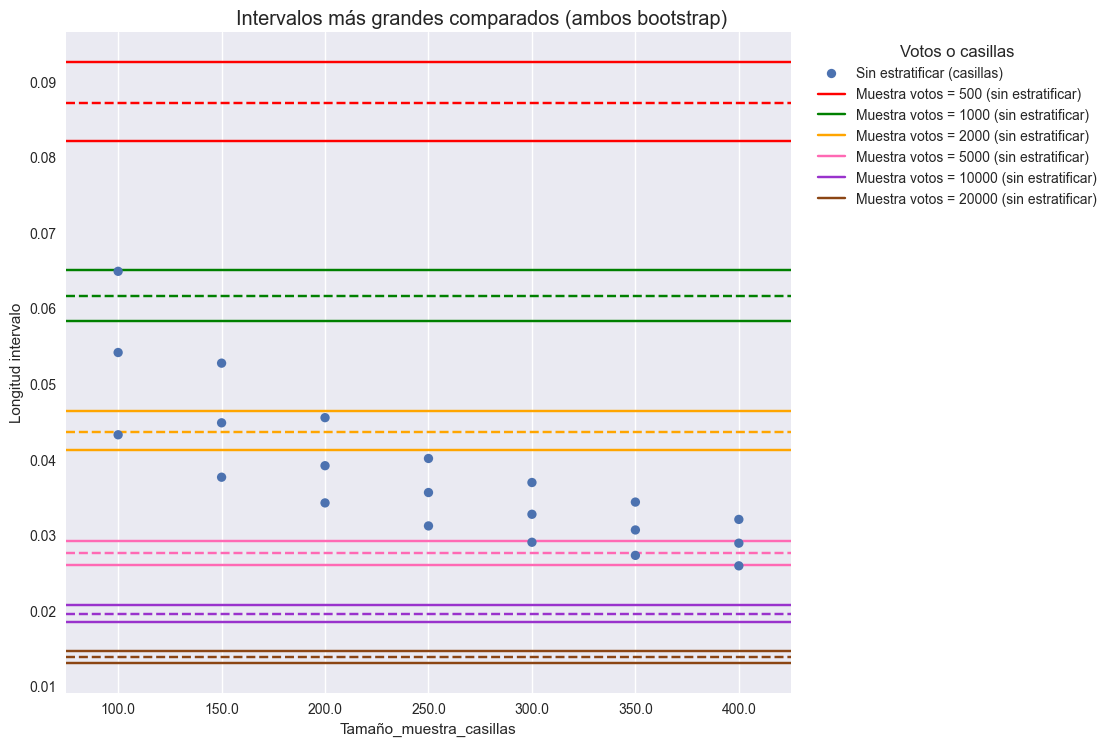

In [143]:
plt.style.use('seaborn-v0_8')
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_im_aux_comb_1=pd.melt(df_boostraps_c_s_e[["Tamaño_muestra_casillas", "Estratificación", "Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_i_e=sns.catplot(data=df_grafica_int_im_aux_comb_1, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', palette="deep", jitter=False, dodge=True, s = 45, height=7.6, aspect=1.1);

per_i_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_i_e.figure.subplots_adjust(top=0.95)
per_i_e.figure.suptitle('Intervalos más grandes comparados (ambos bootstrap)');
# per_i_e.refline(y=0.025, linewidth=1, color='black', ls='--');

colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# extract the catplot artist legend handles
catplot_handles = per_i_e._legend.legend_handles

# make the in built catplot legend invisible
per_i_e._legend.set(visible=False)

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");
plt.grid()

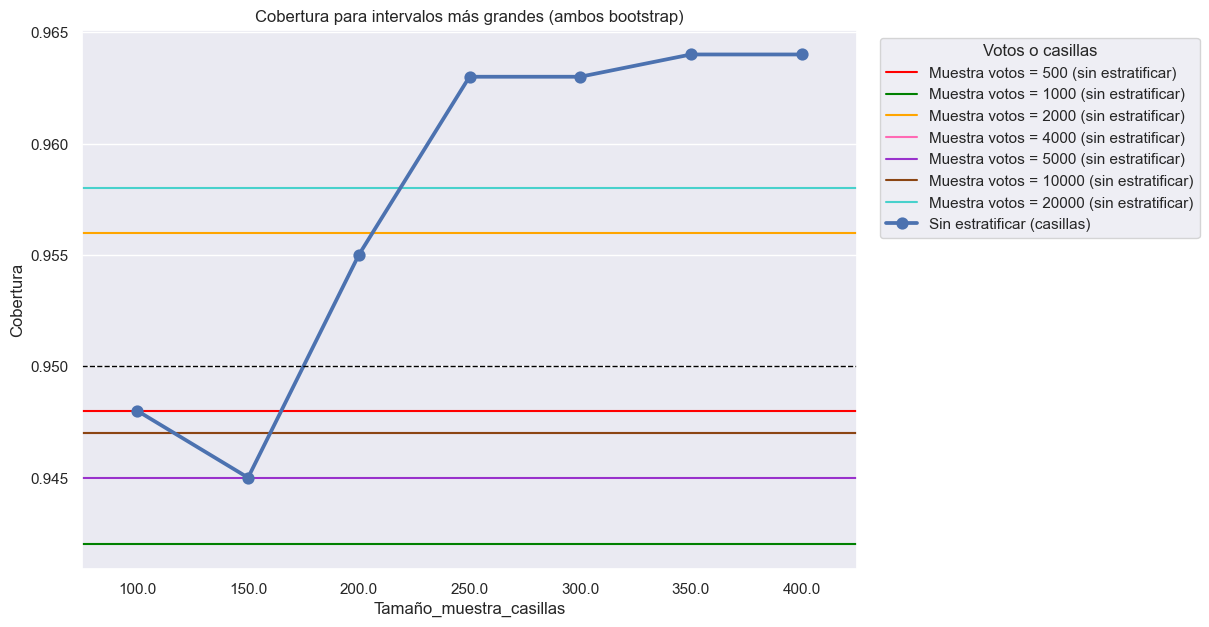

In [7]:
fig, ax = plt.subplots(figsize=(10,7))

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_candidato_cob"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax,
    data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Intervalo_M_grande_candidato_cob", hue="Estratificación"
).set_title("Cobertura para intervalos más grandes (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

# Cambiamos el nombre de la leyenda
plt.legend(title='Votos o casillas');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

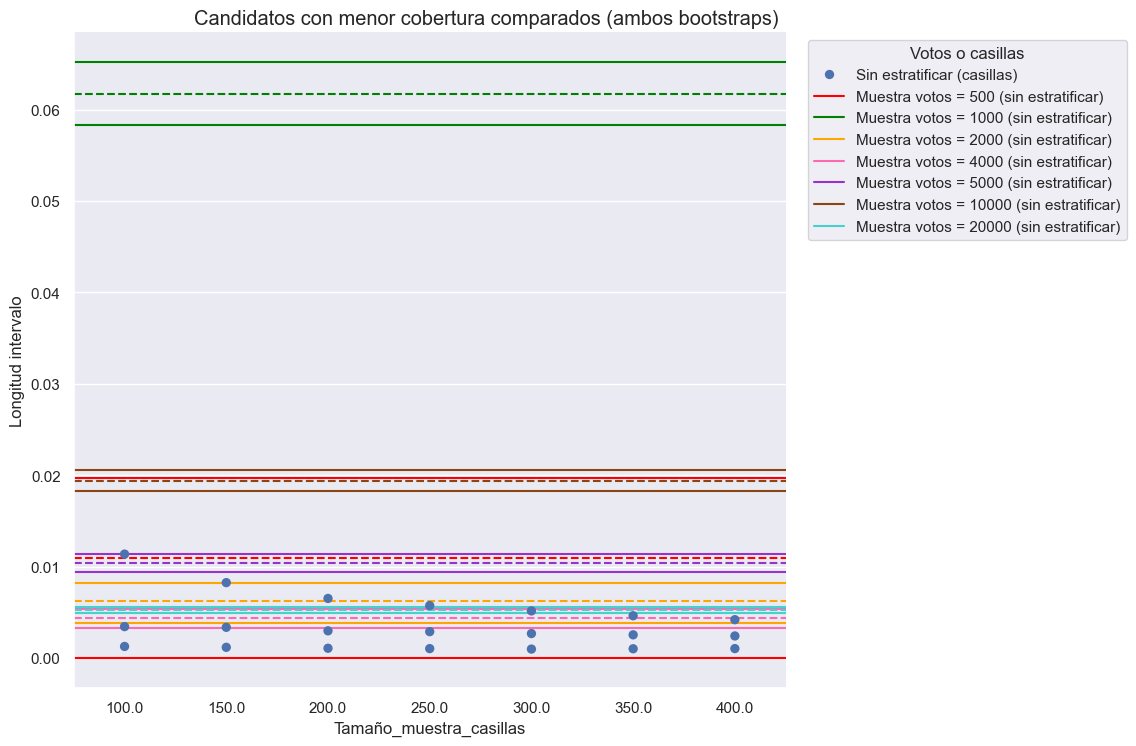

In [8]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_mc_aux_comb_1=pd.melt(df_boostraps_c_s_e[["Tamaño_muestra_casillas", "Estratificación", "Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_mc_e=sns.catplot(data=df_grafica_int_mc_aux_comb_1, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', height=7.6, aspect=1.1, palette="deep", jitter=False, dodge=True, s = 45);

per_mc_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_mc_e.figure.subplots_adjust(top=0.95)
per_mc_e.figure.suptitle('Candidatos con menor cobertura comparados (ambos bootstraps)');
#per_mc_e.refline(y=0.025, linewidth=1, color='black', ls='--');
# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# extract the catplot artist legend handles
catplot_handles = per_mc_e._legend.legend_handles

# make the in built catplot legend invisible
per_mc_e._legend.set(visible=False)

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

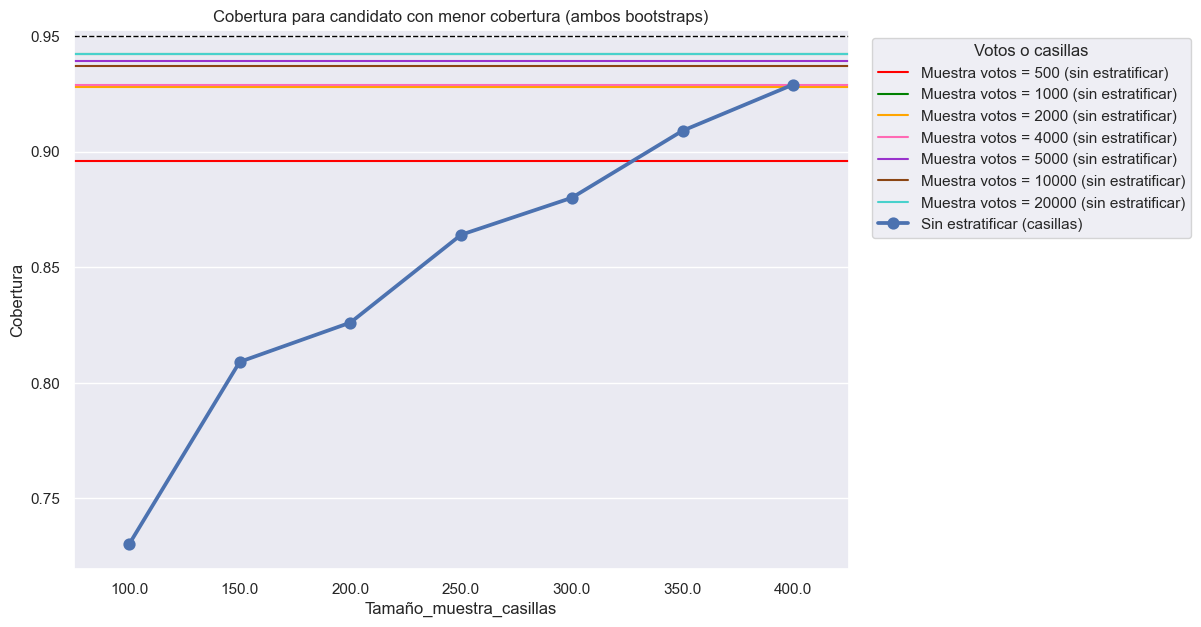

In [9]:
fig, ax = plt.subplots(figsize=(10,7))

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_candidato"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax, data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Cobertura_m_candidato", 
              hue="Estratificación").set_title("Cobertura para candidato con menor cobertura (ambos bootstraps)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

### Gráficas de las coberturas por candidato

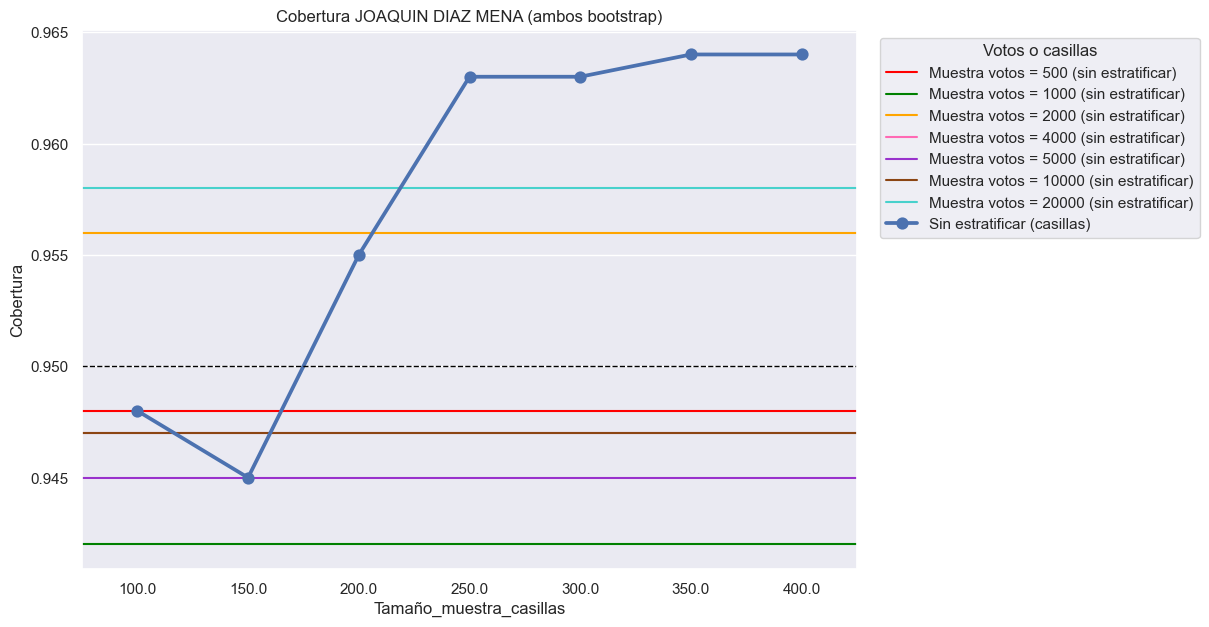

In [10]:
fig, ax = plt.subplots(figsize=(10,7))

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_JOAQUIN_DIAZ_MENA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax,data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Cob_JOAQUIN_DIAZ_MENA", 
        hue="Estratificación").set_title("Cobertura JOAQUIN DIAZ MENA (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

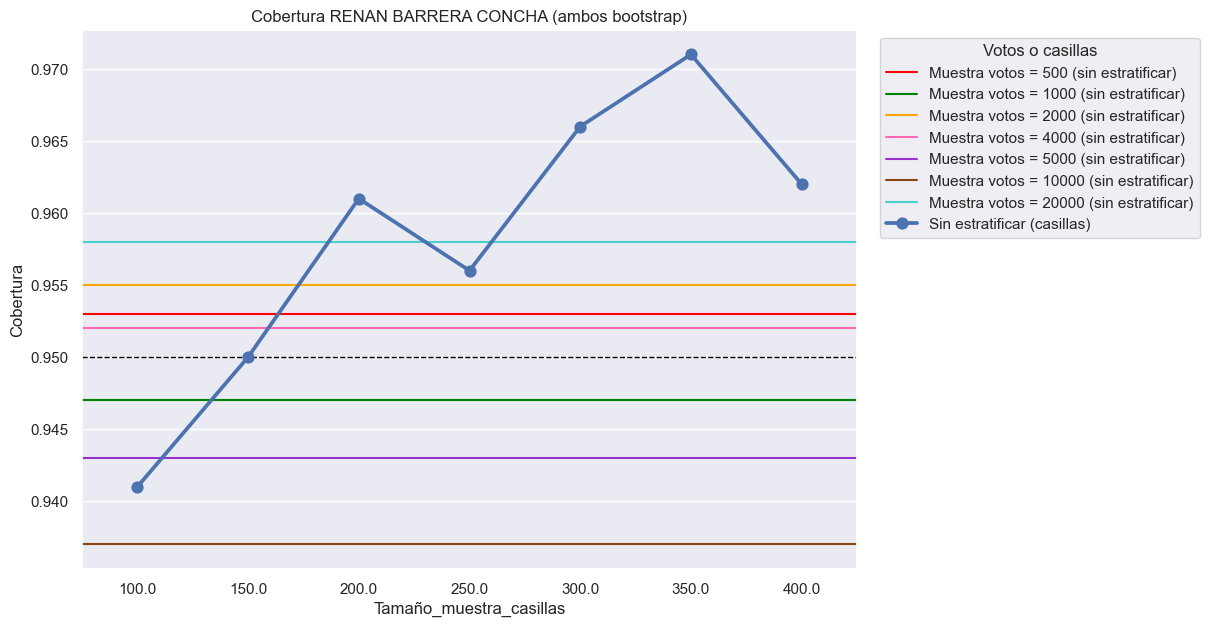

In [11]:
fig, ax = plt.subplots(figsize=(10,7))
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_RENAN_BARRERA_CONCHA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax,data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Cob_RENAN_BARRERA_CONCHA", 
        hue="Estratificación").set_title("Cobertura RENAN BARRERA CONCHA (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

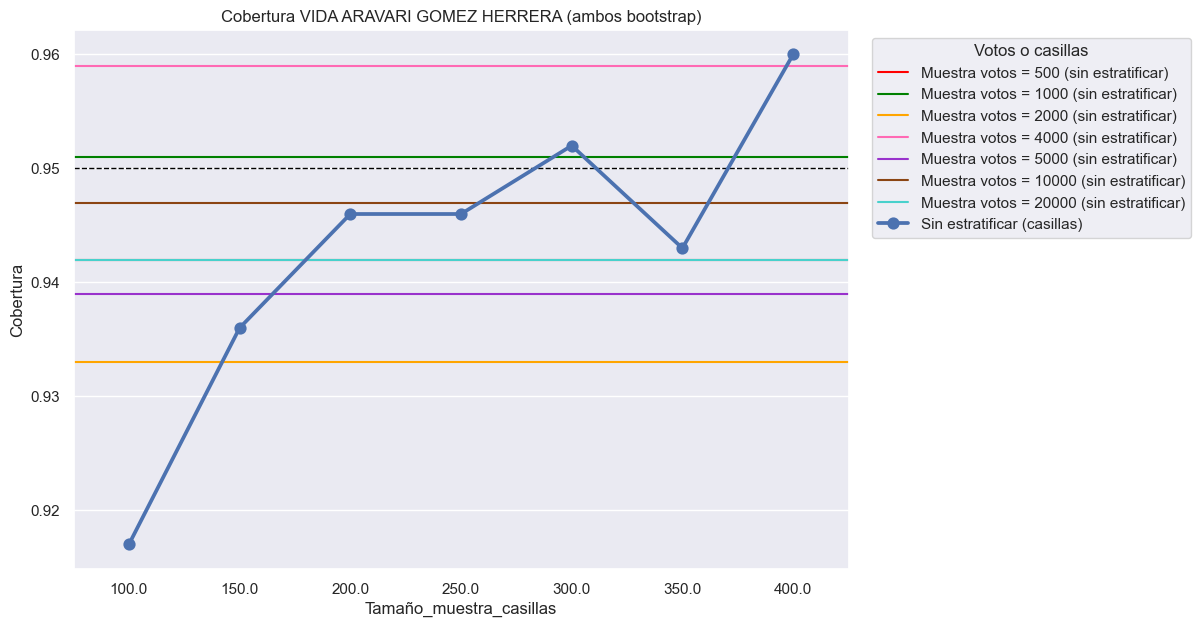

In [12]:
fig, ax = plt.subplots(figsize=(10,7))
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax,data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Cob_VIDA_ARAVARI_GOMEZ_HERRERA", 
        hue="Estratificación").set_title("Cobertura VIDA ARAVARI GOMEZ HERRERA (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

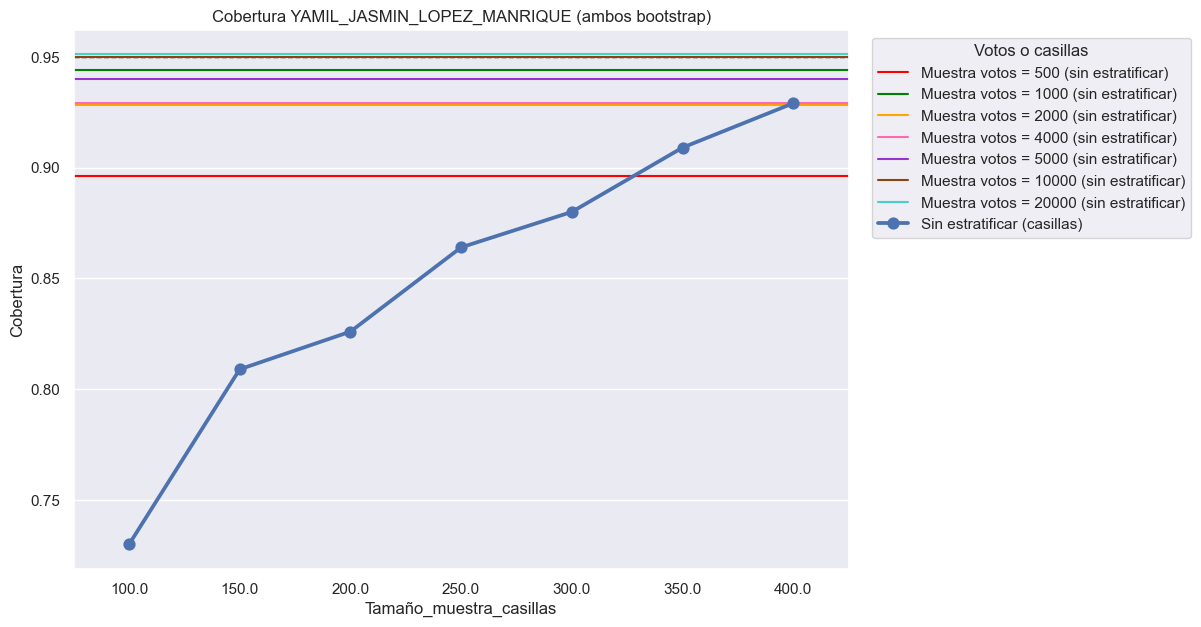

In [13]:
fig, ax = plt.subplots(figsize=(10,7))

ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax,data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE", 
        hue="Estratificación").set_title("Cobertura YAMIL_JASMIN_LOPEZ_MANRIQUE (ambos bootstrap)");
ax.set(ylabel='Cobertura');


# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

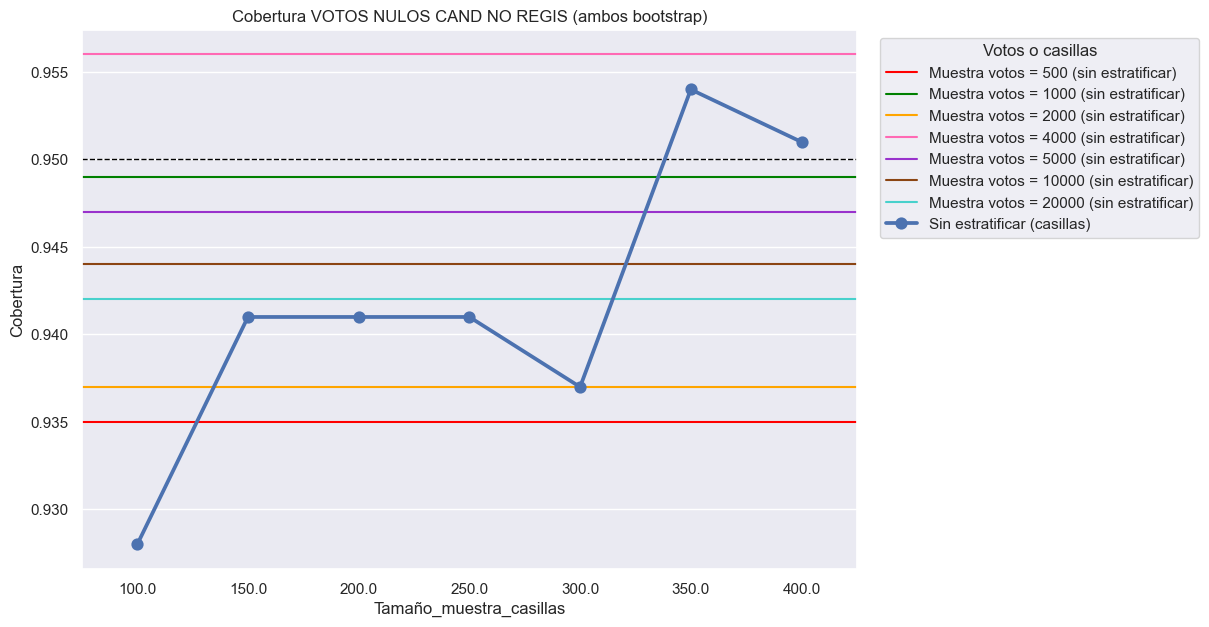

In [14]:
fig, ax = plt.subplots(figsize=(10,7))

ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_se["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_se[df_boostraps_votos_se["Tamaño_muestra_votos"]==i[1]]["Cob_VOTOS_NULOS_CAND_NO_REGIS"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (sin estratificar)");

sns.pointplot(ax=ax,data=df_boostraps_c_s_e, x="Tamaño_muestra_casillas", y="Cob_VOTOS_NULOS_CAND_NO_REGIS", 
        hue="Estratificación").set_title("Cobertura VOTOS NULOS CAND NO REGIS (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Cambiamos el nombre de la leyenda
plt.legend(title='Votos o casillas');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

## Comparación bootstraps estratificados

In [15]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Boostrap por casillas/Distintas_muestras_casillas_bootstrap_estratificado_1.csv", index_col=0)
# Base de bootstrap por votos (directo)
df_boostraps_votos_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Directo/Distintas_muestras_submuestras_bootstrap_votos_dir_estratificado_3_ed_e.csv", index_col=0)

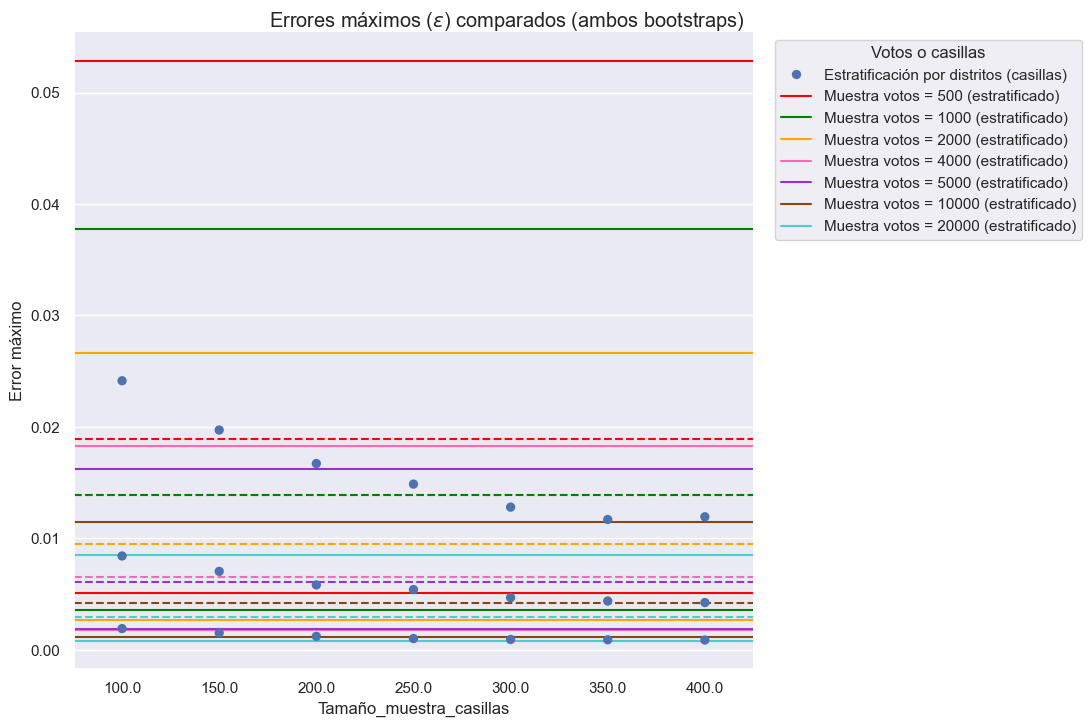

In [16]:
# Para hacer la gráfica del error con los distintos tamaños de la submuestra de votos
df_grafica_error_aux_comb_2=pd.melt(df_boostraps_c_est[["Tamaño_muestra_casillas", "Estratificación", "Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)
per_e_est=sns.catplot(data=df_grafica_error_aux_comb_2, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', palette="deep", jitter=False, dodge=True, s = 45, height=7.4, aspect=1.1);
per_e_est.set(xlabel='Tamaño_muestra_casillas', ylabel='Error máximo')
per_e_est.figure.subplots_adjust(top=0.95)
per_e_est.figure.suptitle('Errores máximos ($\\epsilon$) comparados (ambos bootstraps)');

# Colores para la gráfica
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Error_maximo_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Error_maximo_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');
#per_e.refline(y=0.015, linewidth=1, color='black', ls='--');


# extract the catplot artist legend handles
catplot_handles = per_e_est._legend.legend_handles

# make the in built catplot legend invisible
per_e_est._legend.set(visible=False)

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

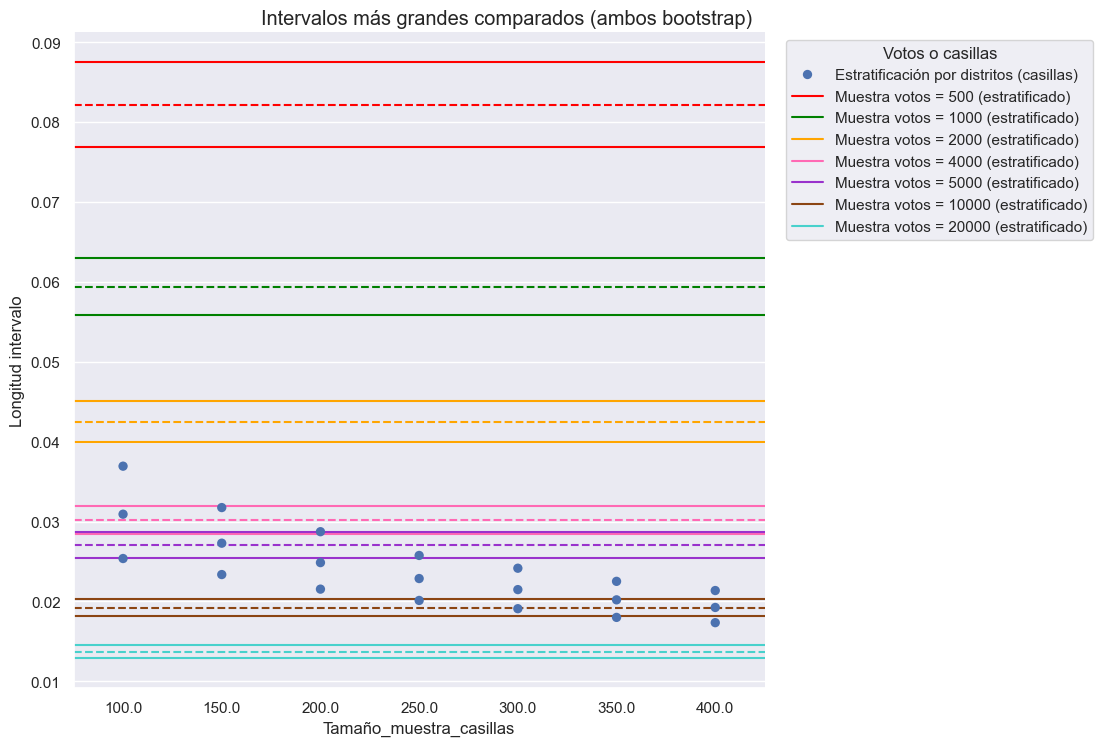

In [17]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_im_aux_comb_2=pd.melt(df_boostraps_c_est[["Tamaño_muestra_casillas", "Estratificación", "Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_i_e_est=sns.catplot(data=df_grafica_int_im_aux_comb_2, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', palette="deep", jitter=False, dodge=True, s = 45, height=7.6, aspect=1.1);

per_i_e_est.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_i_e_est.figure.subplots_adjust(top=0.95)
per_i_e_est.figure.suptitle('Intervalos más grandes comparados (ambos bootstrap)');
# per_i_e.refline(y=0.025, linewidth=1, color='black', ls='--');

colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# extract the catplot artist legend handles
catplot_handles = per_i_e_est._legend.legend_handles

# make the in built catplot legend invisible
per_i_e_est._legend.set(visible=False)

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

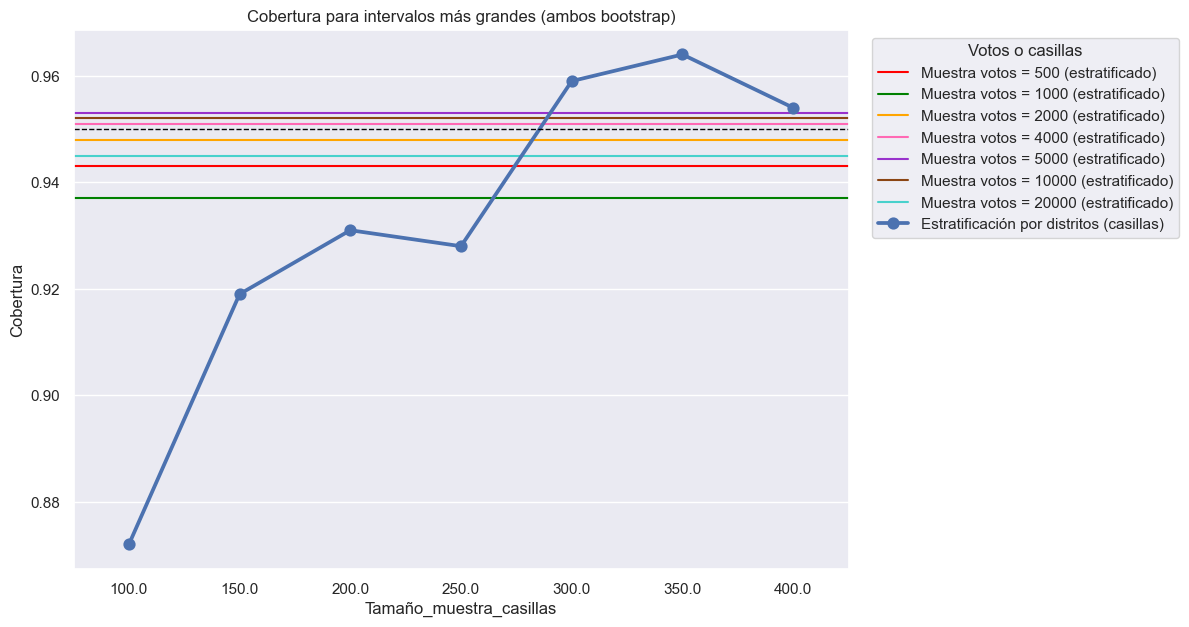

In [18]:
fig, ax = plt.subplots(figsize=(10,7))

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Intervalo_M_grande_candidato_cob"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax,
    data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Intervalo_M_grande_candidato_cob", hue="Estratificación"
).set_title("Cobertura para intervalos más grandes (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");


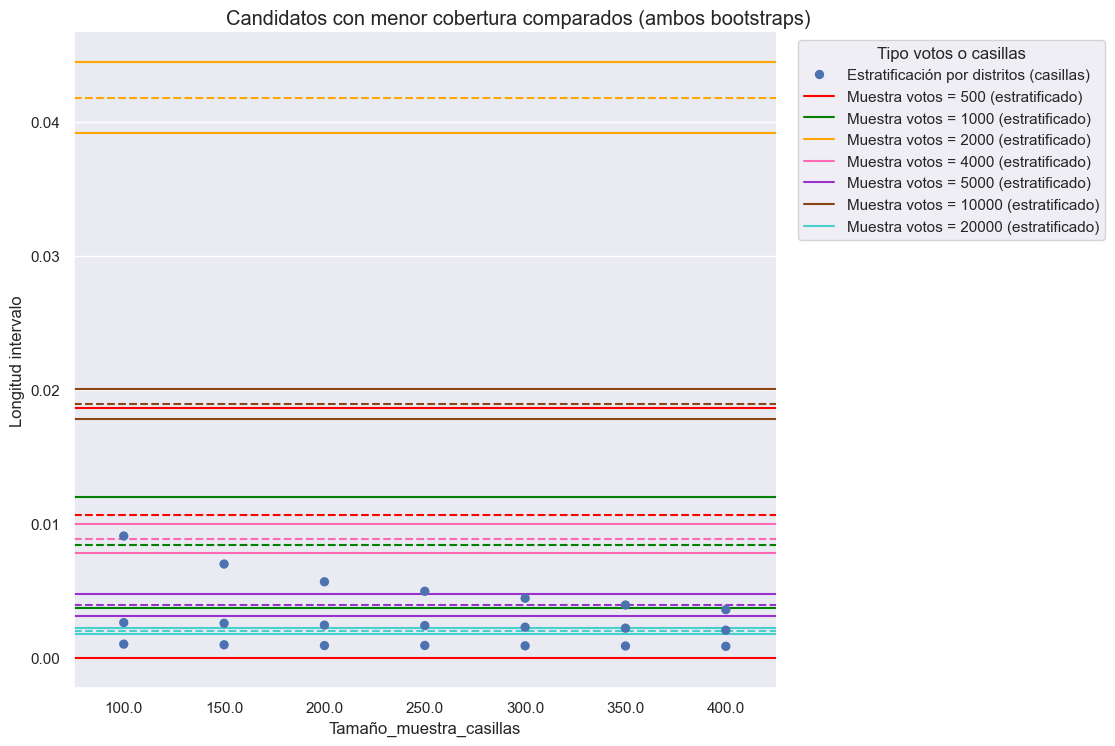

In [19]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_mc_aux_comb_2=pd.melt(df_boostraps_c_est[["Tamaño_muestra_casillas", "Estratificación", "Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_mc_e_est=sns.catplot(data=df_grafica_int_mc_aux_comb_2, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', height=7.6, aspect=1.1, palette="deep", jitter=False, dodge=True, s = 45);

per_mc_e_est.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_mc_e_est.figure.subplots_adjust(top=0.95)
per_mc_e_est.figure.suptitle('Candidatos con menor cobertura comparados (ambos bootstraps)');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_025"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_mediana"].iloc[0], c=colors_plot[i[0]], linestyle='dashed');
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_inter_q_975"].iloc[0], c=colors_plot[i[0]], linestyle='solid');

# extract the catplot artist legend handles
catplot_handles = per_mc_e_est._legend.legend_handles

# make the in built catplot legend invisible
per_mc_e_est._legend.set(visible=False)

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', handles=catplot_handles, bbox_to_anchor=(1.02, 1))
plt.legend(title='Tipo votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

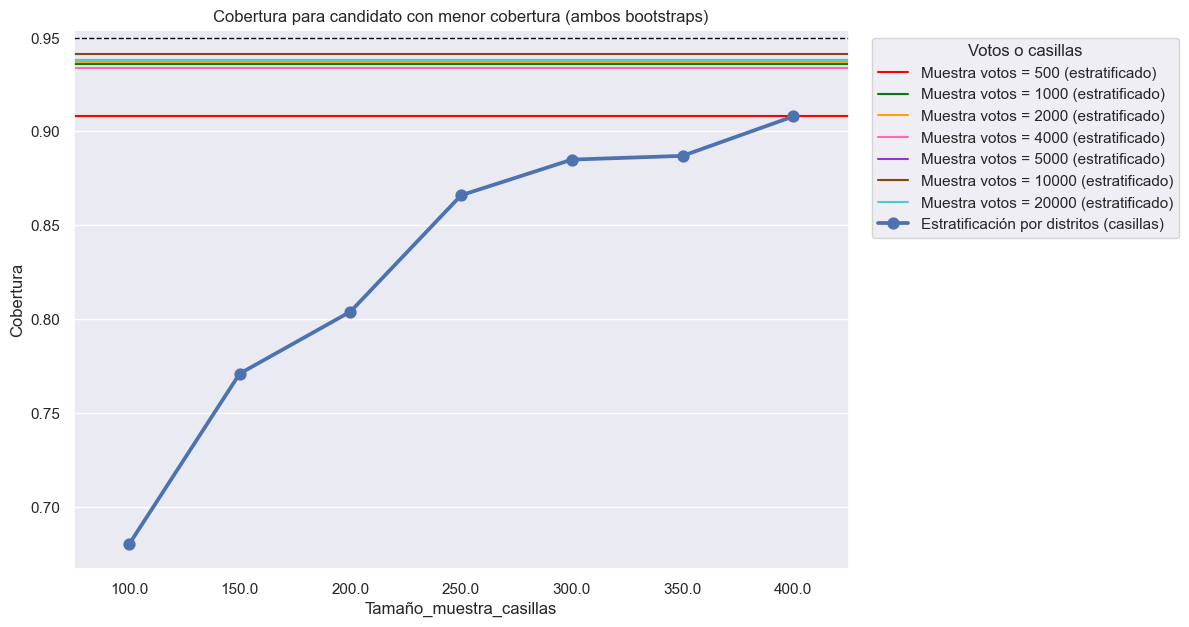

In [20]:
fig, ax = plt.subplots(figsize=(10,7))

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cobertura_m_candidato"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax, data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Cobertura_m_candidato", 
              hue="Estratificación").set_title("Cobertura para candidato con menor cobertura (ambos bootstraps)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

### Gráficas de las coberturas por candidato

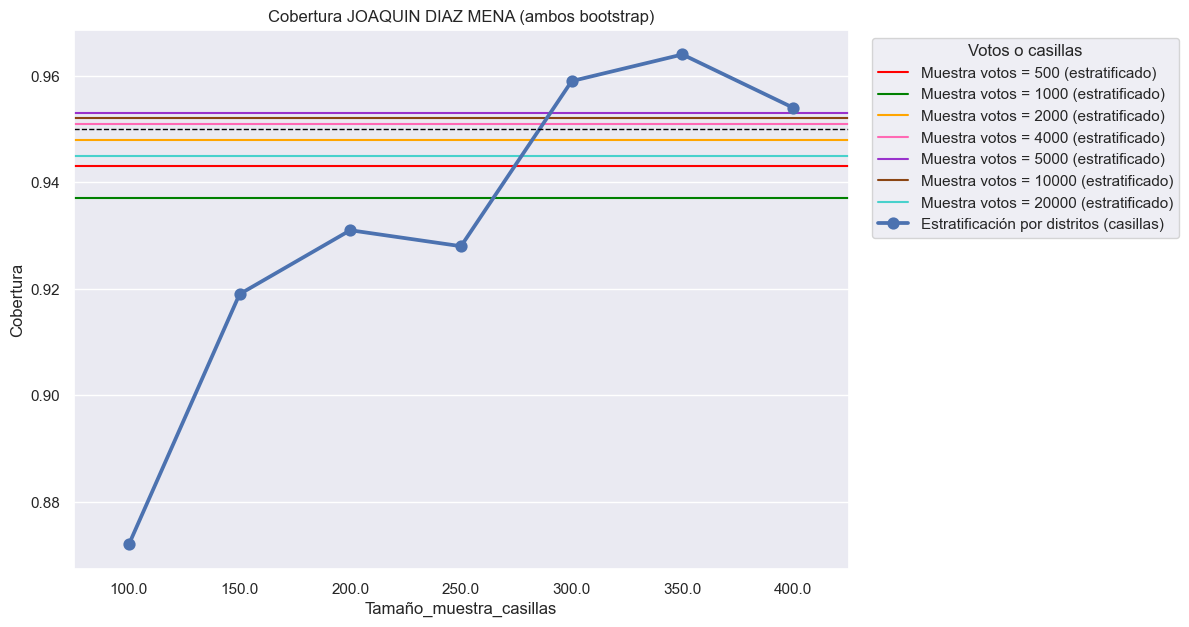

In [21]:
fig, ax = plt.subplots(figsize=(10,7))

# colores de las gráficas
colors_plot=["red","green","orange","hotpink","darkorchid","saddlebrown","mediumturquoise"]

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_JOAQUIN_DIAZ_MENA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax, data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Cob_JOAQUIN_DIAZ_MENA", 
        hue="Estratificación").set_title("Cobertura JOAQUIN DIAZ MENA (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

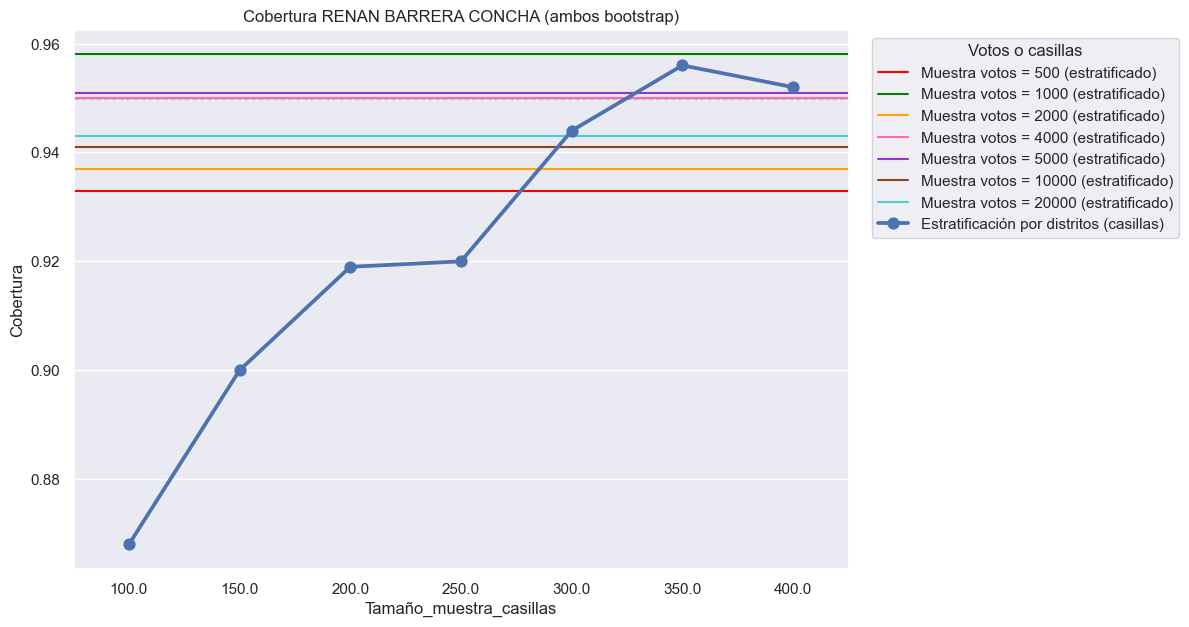

In [22]:
fig, ax = plt.subplots(figsize=(10,7))
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_RENAN_BARRERA_CONCHA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax,data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Cob_RENAN_BARRERA_CONCHA", 
        hue="Estratificación").set_title("Cobertura RENAN BARRERA CONCHA (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

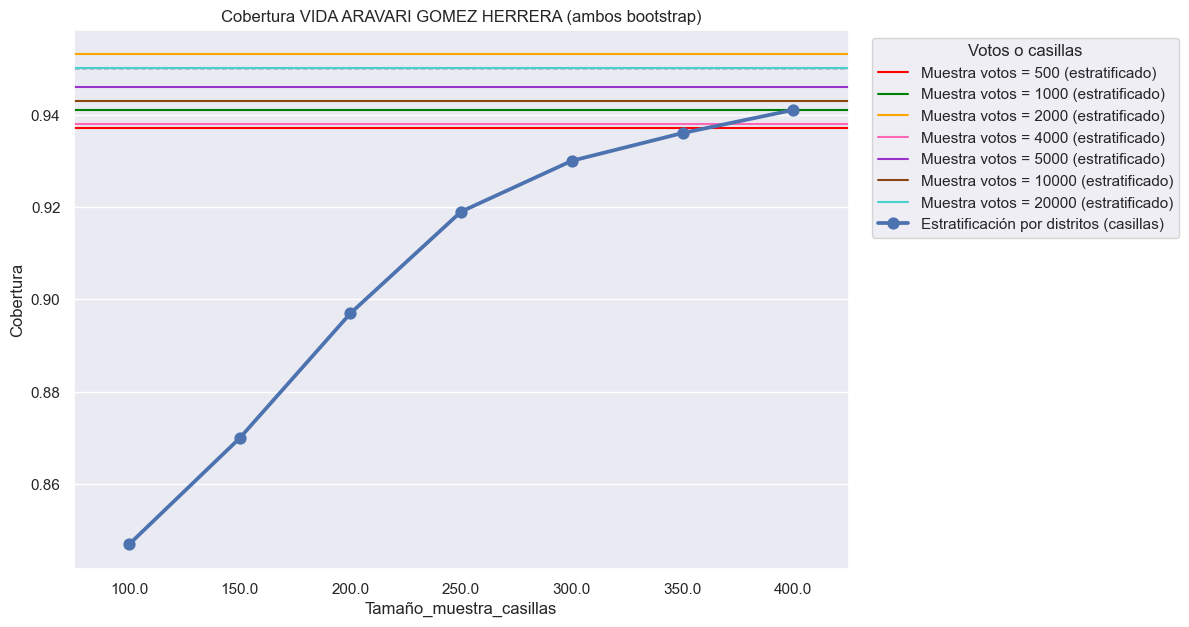

In [23]:
fig, ax = plt.subplots(figsize=(10,7))
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax,data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Cob_VIDA_ARAVARI_GOMEZ_HERRERA", 
        hue="Estratificación").set_title("Cobertura VIDA ARAVARI GOMEZ HERRERA (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

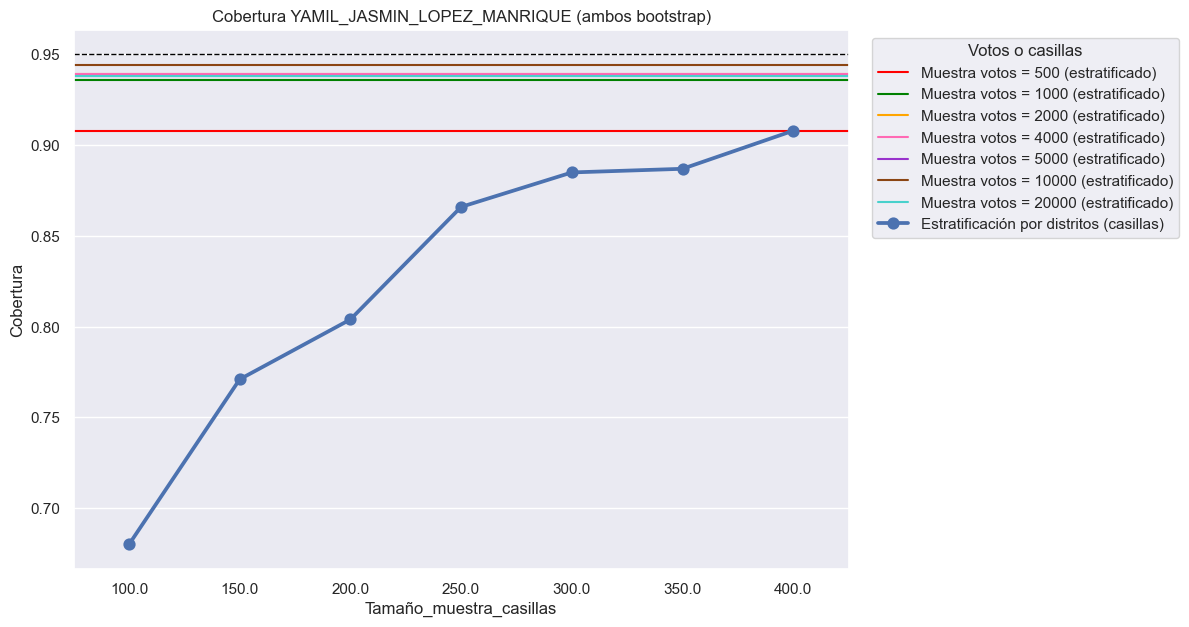

In [24]:
fig, ax = plt.subplots(figsize=(10,7))

ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax,data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE", 
        hue="Estratificación").set_title("Cobertura YAMIL_JASMIN_LOPEZ_MANRIQUE (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");

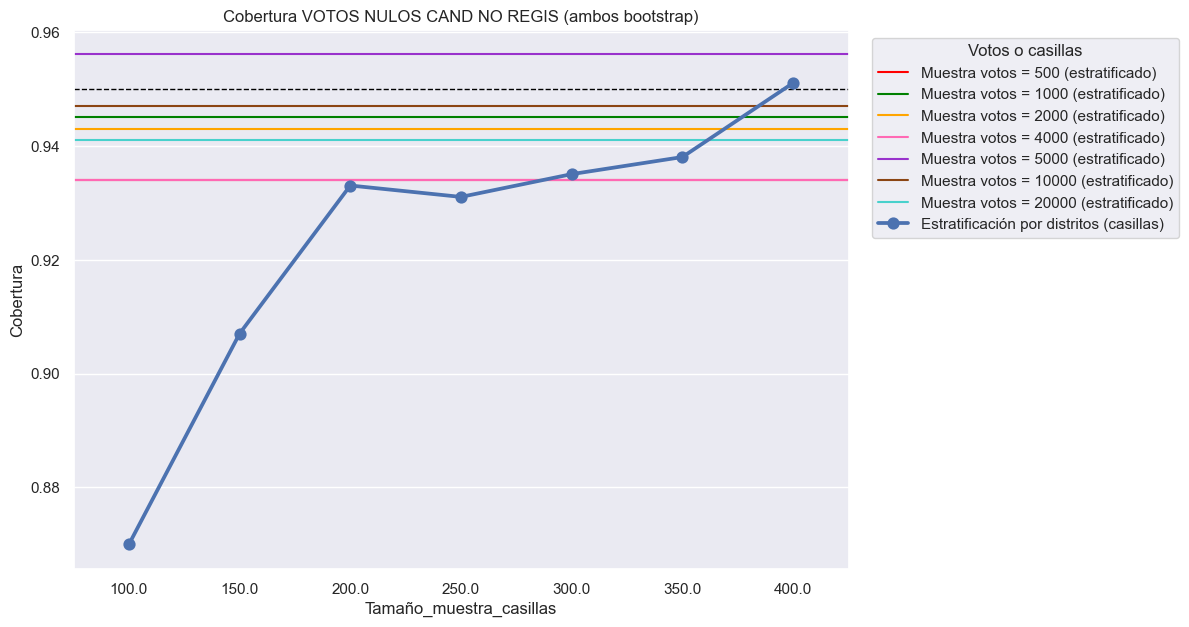

In [25]:
fig, ax = plt.subplots(figsize=(10,7))

ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

# Para graficar todos las rectas de los votos
for i in enumerate(df_boostraps_votos_est["Tamaño_muestra_votos"].astype(int)):
    plt.axhline(y=df_boostraps_votos_est[df_boostraps_votos_est["Tamaño_muestra_votos"]==i[1]]["Cob_VOTOS_NULOS_CAND_NO_REGIS"].iloc[0], c=colors_plot[i[0]], linestyle='solid', label=f"Muestra votos = {i[1]} (estratificado)");

sns.pointplot(ax=ax,data=df_boostraps_c_est, x="Tamaño_muestra_casillas", y="Cob_VOTOS_NULOS_CAND_NO_REGIS", 
        hue="Estratificación").set_title("Cobertura VOTOS NULOS CAND NO REGIS (ambos bootstrap)");
ax.set(ylabel='Cobertura');

# Juntamos los títulos y las leyendas con un nombre
legend2 = plt.legend(loc='upper right', bbox_to_anchor=(1.02, 1))
plt.legend(title='Votos o casillas', bbox_to_anchor=(1.02, 1), loc="upper left");